In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
# Read the CSV file into a DataFrame
travel_data = pd.read_csv('../source-data/travel_data.csv', parse_dates=['Travel_Date', 'Booking_Date', 'Booking_Timestamp'])

# check how many rows and columns we have
travel_data.shape

(519713, 25)

519713 rows and 25 columns

In [3]:
travel_data.head()

,Booking_ID,Customer_ID,Route_ID,Travel_Date,Booking_Date,Booking_Timestamp,Ticket_Price_GBP,Seat_Class,Booking_Channel,Origin,Destination,Distance_km,Route_Category,Customer_Segment,Loyalty_Status,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor
0,B000000087,C000971,R0001,2025-01-01,2024-11-03,2024-11-03 02:38:21,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,NaN,2,17.61,283,167,116,0.798,NaN,58,NaN,0.590106
1,B000000012,C004636,R0001,2025-01-01,2024-11-10,2024-11-10 21:51:11,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,2,41.66,283,167,116,0.798,NaN,51,NaN,0.590106
2,B000000021,C004403,R0001,2025-01-01,2024-11-15,2024-11-15 23:24:12,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,NaN,2,39.07,283,167,116,0.798,NaN,46,NaN,0.590106
3,B000000064,C010229,R0001,2025-01-01,2024-11-18,2024-11-18 00:18:54,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,NaN,4,45.29,283,167,116,0.798,NaN,43,NaN,0.590106
4,B000000077,C009319,R0001,2025-01-01,2024-11-18,2024-11-18 15:02:18,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,NaN,4,50.49,283,167,116,0.798,NaN,43,NaN,0.590106


Already seeing some null values

In [4]:
# check the data types and missing values for each column
travel_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 519713 entries, 0 to 519712
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Booking_ID                519713 non-null  object        
 1   Customer_ID               519713 non-null  object        
 2   Route_ID                  519713 non-null  object        
 3   Travel_Date               519713 non-null  datetime64[ns]
 4   Booking_Date              519713 non-null  datetime64[ns]
 5   Booking_Timestamp         519713 non-null  datetime64[ns]
 6   Ticket_Price_GBP          519713 non-null  float64       
 7   Seat_Class                519713 non-null  object        
 8   Booking_Channel           519713 non-null  object        
 9   Origin                    519713 non-null  object        
 10  Destination               519713 non-null  object        
 11  Distance_km               519713 non-null  int64         
 12  Ro

Columns with null values are Loyalty_Status, Base_Price_At_Booking and Price_Premium 

Text(0.5, 1.0, 'Ticket Price vs Demand Index')

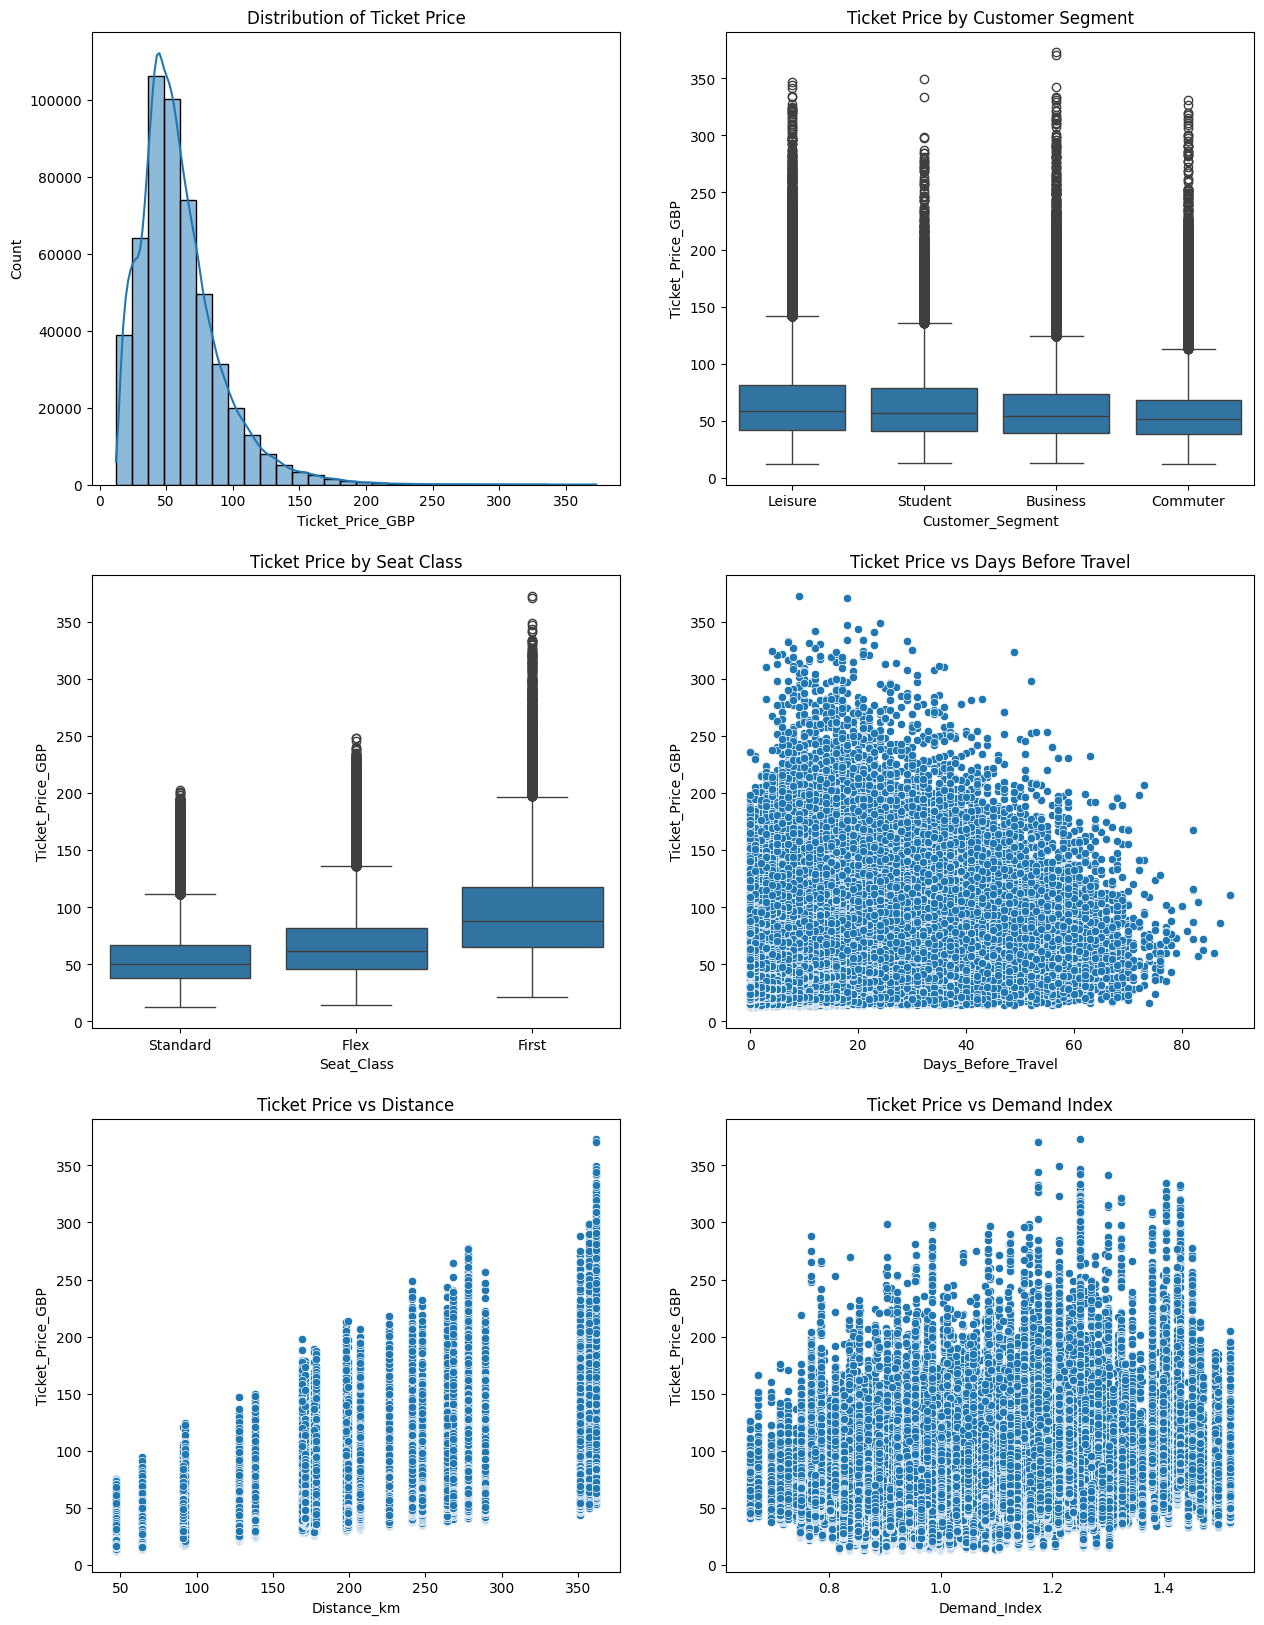

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(15, 20))

# Plot the distribution of Ticket_Price
sns.histplot(travel_data['Ticket_Price_GBP'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Ticket Price')

# Plot boxplot of Ticket_Price by Customer_Segment
sns.boxplot(x='Customer_Segment', y='Ticket_Price_GBP', data=travel_data, ax=axes[0, 1])
axes[0, 1].set_title('Ticket Price by Customer Segment')

# boxplpot of Ticket_Price by Seat_Class
sns.boxplot(x='Seat_Class', y='Ticket_Price_GBP', data=travel_data, ax=axes[1, 0])
axes[1, 0].set_title('Ticket Price by Seat Class')

# scatter plot of Ticket_Price vs days before travel
sns.scatterplot(x='Days_Before_Travel', y='Ticket_Price_GBP', data=travel_data, ax=axes[1, 1])
axes[1, 1].set_title('Ticket Price vs Days Before Travel')

# sctatter plot of Ticket_Price vs Distance
sns.scatterplot(x='Distance_km', y='Ticket_Price_GBP', data=travel_data, ax=axes[2, 0])
axes[2, 0].set_title('Ticket Price vs Distance')

# scatter plot of Ticket_Price vs Demand Index
sns.scatterplot(x='Demand_Index', y='Ticket_Price_GBP', data=travel_data, ax=axes[2, 1])
axes[2, 1].set_title('Ticket Price vs Demand Index')

### Initial Findings

- Ticket Price is normally between £40 and £60 frm distribution. The distribution is also right-skewed.
- Slight correlation between price and days before travel
- No correlation between price and distance. Its unaffected by distance
- Ticket pricing is unaffected too by demand index, confirming the existence of the problem we're trying t solve.
- No percieved outlier as noted by boxplots

In [ ]:
# Confirm that there are no outliers in featured columns using mean and median
travel_data.describe(include=['int64', 'float64'])

,Ticket_Price_GBP,Distance_km,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor
count,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,461445.000000,519713.000000,461445.000000,519713.000000
mean,59.949484,203.925224,5.122545,41.592756,308.997237,254.470173,54.527064,1.070136,52.871776,7.849571,5.394408,0.823364
std,30.365550,86.959412,2.776248,17.236907,71.364323,74.822934,45.034976,0.176269,24.313223,10.580809,11.720304,0.137679
min,12.290000,47.000000,0.000000,10.000000,140.000000,81.000000,3.000000,0.658000,13.360000,0.000000,-14.220000,0.332308
25%,39.800000,169.000000,3.000000,29.780000,258.000000,194.000000,11.000000,0.940000,36.970000,0.000000,-0.310000,0.723810
50%,54.150000,198.000000,5.000000,38.880000,319.000000,248.000000,47.000000,1.055000,49.060000,4.000000,1.060000,0.839161
75%,73.670000,264.000000,7.000000,50.060000,365.000000,315.000000,84.000000,1.190000,64.820000,11.000000,6.490000,0.961686
max,372.860000,362.000000,18.000000,125.520000,420.000000,412.000000,235.000000,1.520000,186.110000,89.000000,191.110000,0.982857


Since mean is sensitive to outliers, we can detect its presence (outlier) if the value of the mean is far off from the median. This doesn't appear to be the case with our columns.

In [ ]:
travel_data.describe(include=['object'])

,Booking_ID,Customer_ID,Route_ID,Seat_Class,Booking_Channel,Origin,Destination,Route_Category,Customer_Segment,Loyalty_Status
count,519713,519713,519713,519713,519713,519713,519713,519713,519713,228746
unique,519713,12000,25,3,4,19,15,3,4,3
top,B000000087,C007411,R0003,Standard,Mobile,Sheffield,London,Medium,Commuter,Silver
freq,1,205,31635,374168,233505,61608,62920,362812,221621,131981


In [ ]:
# check for duplicates in dataset
print(travel_data.duplicated().sum())

0


No duplicates in our dataset

### Investigating Null Values

In [ ]:
travel_data[travel_data.isnull().any(axis=1)]

,Booking_ID,Customer_ID,Route_ID,Travel_Date,Booking_Date,Booking_Timestamp,Ticket_Price_GBP,Seat_Class,Booking_Channel,Origin,Destination,Distance_km,Route_Category,Customer_Segment,Loyalty_Status,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor
0,B000000087,C000971,R0001,2025-01-01,2024-11-03,2024-11-03 02:38:21,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,NaN,2,17.61,283,167,116,0.798,NaN,58,NaN,0.590106
1,B000000012,C004636,R0001,2025-01-01,2024-11-10,2024-11-10 21:51:11,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,2,41.66,283,167,116,0.798,NaN,51,NaN,0.590106
2,B000000021,C004403,R0001,2025-01-01,2024-11-15,2024-11-15 23:24:12,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,NaN,2,39.07,283,167,116,0.798,NaN,46,NaN,0.590106
3,B000000064,C010229,R0001,2025-01-01,2024-11-18,2024-11-18 00:18:54,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,NaN,4,45.29,283,167,116,0.798,NaN,43,NaN,0.590106
4,B000000077,C009319,R0001,2025-01-01,2024-11-18,2024-11-18 15:02:18,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,NaN,4,50.49,283,167,116,0.798,NaN,43,NaN,0.590106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519705,B000519701,C007256,R0025,2025-03-31,2025-03-30,2025-03-30 21:05:00,41.92,Standard,Mobile,York,Liverpool,171,Medium,Commuter,NaN,7,43.56,160,129,31,1.125,41.61,0,0.31,0.806250
519706,B000519679,C003207,R0025,2025-03-31,2025-03-30,2025-03-30 21:33:00,48.43,Flex,Mobile,York,Liverpool,171,Medium,Leisure,NaN,4,39.44,160,129,31,1.125,41.61,0,6.82,0.806250
519707,B000519709,C010000,R0025,2025-03-31,2025-03-30,2025-03-30 21:53:00,54.85,Flex,Agent,York,Liverpool,171,Medium,Leisure,NaN,2,38.87,160,129,31,1.125,41.61,0,13.24,0.806250
519708,B000519626,C008435,R0025,2025-03-31,2025-03-30,2025-03-30 22:30:00,40.17,Standard,Web,York,Liverpool,171,Medium,Leisure,NaN,1,26.56,160,129,31,1.125,41.61,0,-1.44,0.806250


317037 records have at least one null field present

In [ ]:
# check the percentage of missing values in each column
travel_data.isnull().mean() * 100

Booking_ID                   0.000000
Customer_ID                  0.000000
Route_ID                     0.000000
Travel_Date                  0.000000
Booking_Date                 0.000000
Booking_Timestamp            0.000000
Ticket_Price_GBP             0.000000
Seat_Class                   0.000000
Booking_Channel              0.000000
Origin                       0.000000
Destination                  0.000000
Distance_km                  0.000000
Route_Category               0.000000
Customer_Segment             0.000000
Loyalty_Status              55.986092
Booking_Frequency_Qtr        0.000000
Average_Spend_GBP            0.000000
Total_Seats                  0.000000
Seats_Sold_Realized          0.000000
Remaining_Seats_Realized     0.000000
Demand_Index                 0.000000
Base_Price_At_Booking       11.211573
Days_Before_Travel           0.000000
Price_Premium               11.211573
Load_Factor                  0.000000
dtype: float64

Base_Price_At_Booking and Price_Premium have the exact same % of null values. We have to check if its just a coincidence or a pattern for the dataset

In [ ]:
travel_data[['Price_Premium', 'Base_Price_At_Booking']].isnull()

,Price_Premium,Base_Price_At_Booking
0,True,True
1,True,True
2,True,True
3,True,True
4,True,True
...,...,...
519708,False,False
519709,False,False
519710,False,False
519711,False,False


Looks like a pattern, definitely.

In [ ]:
# checking to see if Ticket_Price_GBP completes the pattern of missing values in Price_Premium and Base_Price_At_Booking
travel_data[['Base_Price_At_Booking', 'Price_Premium', 'Ticket_Price_GBP']]

,Base_Price_At_Booking,Price_Premium,Ticket_Price_GBP
0,NaN,NaN,51.81
1,NaN,NaN,53.74
2,NaN,NaN,69.01
3,NaN,NaN,98.86
4,NaN,NaN,56.89
...,...,...,...
519708,41.61,-1.44,40.17
519709,41.61,-0.54,41.07
519710,41.61,-0.72,40.89
519711,41.61,-0.09,41.52


This makes sense given industry knowledge regarding price premiums (add-ons/discounts) when booking tickets. This means that we can use Ticket price to fill in null values for base price and price premuim will be the difference ticket price and base price.

In [ ]:
travel_data[['Base_Price_At_Booking', 'Price_Premium', 'Ticket_Price_GBP', 'Loyalty_Status']].head(50)

,Base_Price_At_Booking,Price_Premium,Ticket_Price_GBP,Loyalty_Status
0,NaN,NaN,51.81,NaN
1,NaN,NaN,53.74,Gold
2,NaN,NaN,69.01,NaN
3,NaN,NaN,98.86,NaN
4,NaN,NaN,56.89,NaN
5,NaN,NaN,62.12,NaN
6,NaN,NaN,57.38,Silver
7,NaN,NaN,55.23,NaN
8,NaN,NaN,74.30,NaN
9,NaN,NaN,57.38,NaN


Loyalty status doesn't hold any concrete pattern for its null values as the other three columns. Its safe to assume it is null because there is no status yet attached to that customer.

In [ ]:
# check if all four columns have the same pattern of missing values for First Class
travel_data[['Base_Price_At_Booking', 'Price_Premium', 'Ticket_Price_GBP', 'Loyalty_Status']][travel_data['Seat_Class'] == 'First'].head(50)

,Base_Price_At_Booking,Price_Premium,Ticket_Price_GBP,Loyalty_Status
3,NaN,NaN,98.86,NaN
64,51.82,52.01,103.83,Silver
104,48.08,26.54,74.62,NaN
121,48.08,42.68,90.76,NaN
131,48.08,33.30,81.38,NaN
182,NaN,NaN,88.75,NaN
189,NaN,NaN,85.78,NaN
198,NaN,NaN,86.63,Platinum
212,NaN,NaN,88.27,Silver
215,55.42,49.43,104.85,NaN


Not the case.

### Handling Null Values

In [3]:
# Loyalty_Status has 20% missing values, but it is not related to the missing values in the other three columns. \
    # We will fill the missing values in Loyalty_Status with 'None' to indicate that these customers do not have a loyalty status.
travel_data['Loyalty_Status'] = travel_data['Loyalty_Status'].fillna('None')

travel_data.head()

,Booking_ID,Customer_ID,Route_ID,Travel_Date,Booking_Date,Booking_Timestamp,Ticket_Price_GBP,Seat_Class,Booking_Channel,Origin,Destination,Distance_km,Route_Category,Customer_Segment,Loyalty_Status,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor
0,B000000087,C000971,R0001,2025-01-01,2024-11-03,2024-11-03 02:38:21,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,None,2,17.61,283,167,116,0.798,NaN,58,NaN,0.590106
1,B000000012,C004636,R0001,2025-01-01,2024-11-10,2024-11-10 21:51:11,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,2,41.66,283,167,116,0.798,NaN,51,NaN,0.590106
2,B000000021,C004403,R0001,2025-01-01,2024-11-15,2024-11-15 23:24:12,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,None,2,39.07,283,167,116,0.798,NaN,46,NaN,0.590106
3,B000000064,C010229,R0001,2025-01-01,2024-11-18,2024-11-18 00:18:54,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,None,4,45.29,283,167,116,0.798,NaN,43,NaN,0.590106
4,B000000077,C009319,R0001,2025-01-01,2024-11-18,2024-11-18 15:02:18,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,None,4,50.49,283,167,116,0.798,NaN,43,NaN,0.590106


In [4]:
# confirm that there is no record where base price at booking and price premium does not have the same pattern of missing values
travel_data[travel_data['Base_Price_At_Booking'].isnull() != travel_data['Price_Premium'].isnull()]

,Booking_ID,Customer_ID,Route_ID,Travel_Date,Booking_Date,Booking_Timestamp,Ticket_Price_GBP,Seat_Class,Booking_Channel,Origin,Destination,Distance_km,Route_Category,Customer_Segment,Loyalty_Status,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor


Confirmed. So we can go ahead and fill them

In [4]:
# filling the missing values in Base_Price_At_Booking with Ticket_Price_GBP
travel_data['Base_Price_At_Booking'] = travel_data['Base_Price_At_Booking'].fillna(travel_data['Ticket_Price_GBP'])

# filling the missing values in Price_Premium with the difference between Ticket_Price_GBP and Base_Price_At_Booking
travel_data['Price_Premium'] = travel_data['Price_Premium'].fillna(travel_data['Ticket_Price_GBP'] - travel_data['Base_Price_At_Booking'])

travel_data.head()

,Booking_ID,Customer_ID,Route_ID,Travel_Date,Booking_Date,Booking_Timestamp,Ticket_Price_GBP,Seat_Class,Booking_Channel,Origin,Destination,Distance_km,Route_Category,Customer_Segment,Loyalty_Status,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor
0,B000000087,C000971,R0001,2025-01-01,2024-11-03,2024-11-03 02:38:21,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,None,2,17.61,283,167,116,0.798,51.81,58,0.0,0.590106
1,B000000012,C004636,R0001,2025-01-01,2024-11-10,2024-11-10 21:51:11,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,2,41.66,283,167,116,0.798,53.74,51,0.0,0.590106
2,B000000021,C004403,R0001,2025-01-01,2024-11-15,2024-11-15 23:24:12,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,None,2,39.07,283,167,116,0.798,69.01,46,0.0,0.590106
3,B000000064,C010229,R0001,2025-01-01,2024-11-18,2024-11-18 00:18:54,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,None,4,45.29,283,167,116,0.798,98.86,43,0.0,0.590106
4,B000000077,C009319,R0001,2025-01-01,2024-11-18,2024-11-18 15:02:18,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,None,4,50.49,283,167,116,0.798,56.89,43,0.0,0.590106


In [ ]:
# confirm that there are no remaining missing values in our dataset
travel_data.isnull().mean() * 100

Booking_ID                  0.0
Customer_ID                 0.0
Route_ID                    0.0
Travel_Date                 0.0
Booking_Date                0.0
Booking_Timestamp           0.0
Ticket_Price_GBP            0.0
Seat_Class                  0.0
Booking_Channel             0.0
Origin                      0.0
Destination                 0.0
Distance_km                 0.0
Route_Category              0.0
Customer_Segment            0.0
Loyalty_Status              0.0
Booking_Frequency_Qtr       0.0
Average_Spend_GBP           0.0
Total_Seats                 0.0
Seats_Sold_Realized         0.0
Remaining_Seats_Realized    0.0
Demand_Index                0.0
Base_Price_At_Booking       0.0
Days_Before_Travel          0.0
Price_Premium               0.0
Load_Factor                 0.0
dtype: float64

## EDA

In [5]:
numeric_cols = travel_data.select_dtypes(include=['int', 'float']).columns.to_list()

numeric_cols

['Ticket_Price_GBP',
 'Distance_km',
 'Booking_Frequency_Qtr',
 'Average_Spend_GBP',
 'Total_Seats',
 'Seats_Sold_Realized',
 'Remaining_Seats_Realized',
 'Demand_Index',
 'Base_Price_At_Booking',
 'Days_Before_Travel',
 'Price_Premium',
 'Load_Factor']

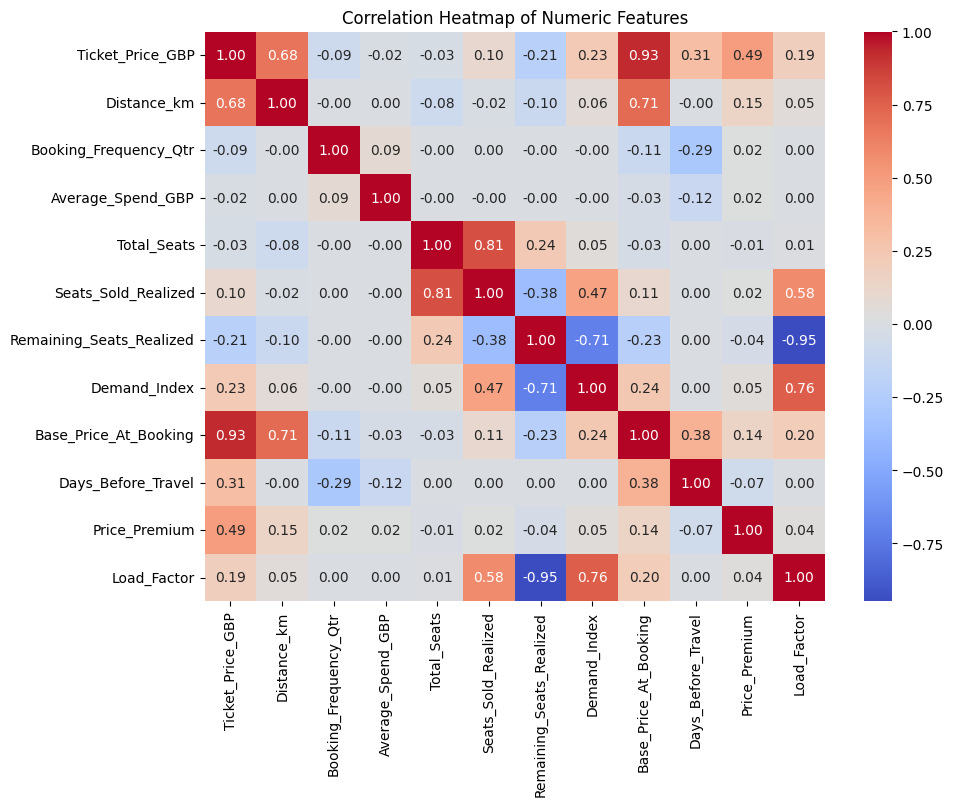

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(travel_data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

Text(0, 0.5, 'Load Factor')

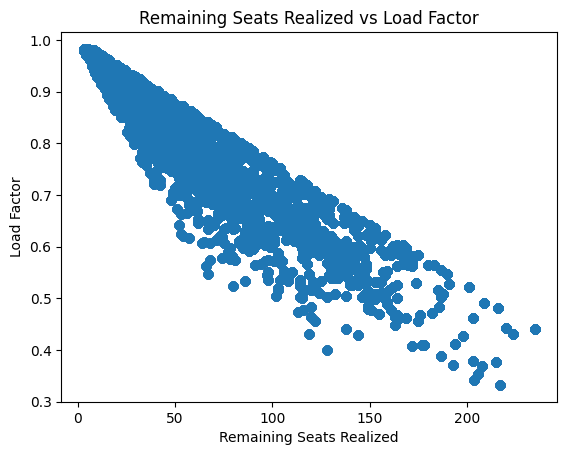

In [ ]:
plt.scatter(travel_data['Remaining_Seats_Realized'], travel_data['Load_Factor'])
plt.title('Remaining Seats Realized vs Load Factor')
plt.xlabel('Remaining Seats Realized')
plt.ylabel('Load Factor')

Text(0, 0.5, 'Ticket Price in GBP')

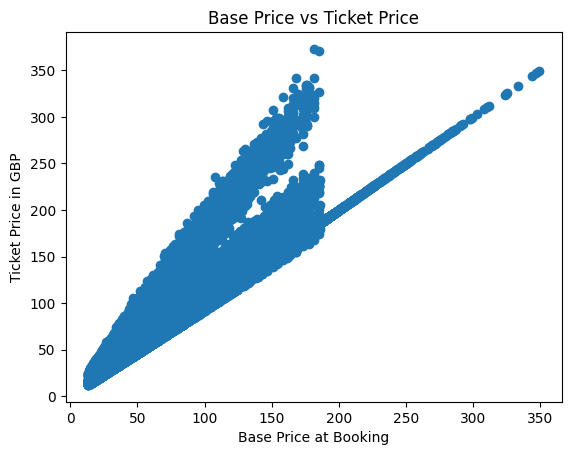

In [ ]:
plt.scatter(travel_data['Base_Price_At_Booking'], travel_data['Ticket_Price_GBP'])
plt.title('Base Price vs Ticket Price')
plt.xlabel('Base Price at Booking')
plt.ylabel('Ticket Price in GBP')

In [ ]:
travel_data

,Booking_ID,Customer_ID,Route_ID,Travel_Date,Booking_Date,Booking_Timestamp,Ticket_Price_GBP,Seat_Class,Booking_Channel,Origin,Destination,Distance_km,Route_Category,Customer_Segment,Loyalty_Status,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor
0,B000000087,C000971,R0001,2025-01-01,2024-11-03,2024-11-03 02:38:21,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,None,2,17.61,283,167,116,0.798,51.81,58,0.00,0.590106
1,B000000012,C004636,R0001,2025-01-01,2024-11-10,2024-11-10 21:51:11,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,2,41.66,283,167,116,0.798,53.74,51,0.00,0.590106
2,B000000021,C004403,R0001,2025-01-01,2024-11-15,2024-11-15 23:24:12,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,None,2,39.07,283,167,116,0.798,69.01,46,0.00,0.590106
3,B000000064,C010229,R0001,2025-01-01,2024-11-18,2024-11-18 00:18:54,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,None,4,45.29,283,167,116,0.798,98.86,43,0.00,0.590106
4,B000000077,C009319,R0001,2025-01-01,2024-11-18,2024-11-18 15:02:18,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,None,4,50.49,283,167,116,0.798,56.89,43,0.00,0.590106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519708,B000519626,C008435,R0025,2025-03-31,2025-03-30,2025-03-30 22:30:00,40.17,Standard,Web,York,Liverpool,171,Medium,Leisure,None,1,26.56,160,129,31,1.125,41.61,0,-1.44,0.806250
519709,B000519663,C004637,R0025,2025-03-31,2025-03-30,2025-03-30 22:36:00,41.07,Standard,Mobile,York,Liverpool,171,Medium,Commuter,Gold,10,33.14,160,129,31,1.125,41.61,0,-0.54,0.806250
519710,B000519649,C008337,R0025,2025-03-31,2025-03-30,2025-03-30 22:56:00,40.89,Standard,Web,York,Liverpool,171,Medium,Commuter,Silver,10,28.48,160,129,31,1.125,41.61,0,-0.72,0.806250
519711,B000519653,C007454,R0025,2025-03-31,2025-03-30,2025-03-30 23:07:00,41.52,Standard,Web,York,Liverpool,171,Medium,Leisure,Silver,2,44.50,160,129,31,1.125,41.61,0,-0.09,0.806250


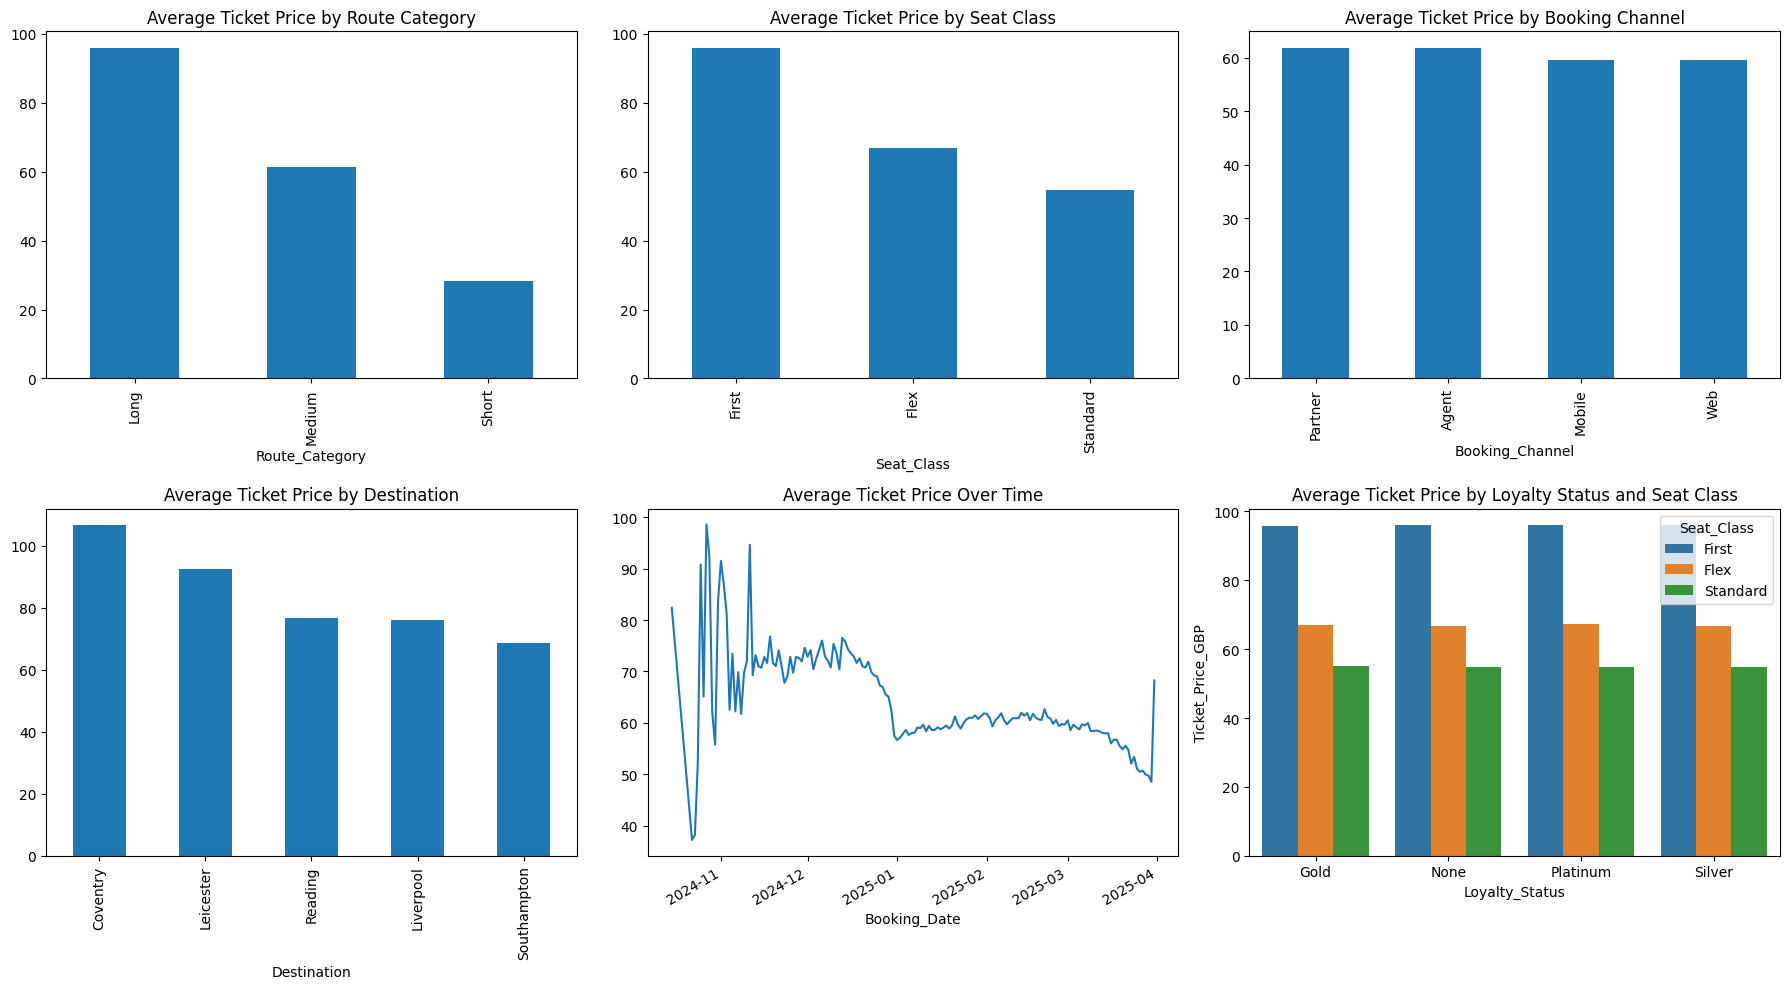

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

travel_data.groupby("Route_Category")["Ticket_Price_GBP"].mean().plot(
    kind="bar", ax=axes[0, 0]
)
axes[0, 0].set_title("Average Ticket Price by Route Category")

travel_data.groupby("Seat_Class")["Ticket_Price_GBP"].mean().plot(
    kind="bar", ax=axes[0, 1]
)
axes[0, 1].set_title("Average Ticket Price by Seat Class")

travel_data.groupby("Booking_Channel")["Ticket_Price_GBP"].mean().sort_values(
    ascending=False
).plot(kind="bar", ax=axes[0, 2])
axes[0, 2].set_title("Average Ticket Price by Booking Channel")

travel_data.groupby("Destination")["Ticket_Price_GBP"].mean().sort_values(
    ascending=False
).head(5).plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Average Ticket Price by Destination")

ticket_price_over_time = (
    travel_data.groupby("Booking_Date")["Ticket_Price_GBP"].mean().sort_index()
)

ticket_price_over_time.plot(ax=axes[1, 1])
axes[1, 1].set_title("Average Ticket Price Over Time")

loyalty_seat_class = (
    travel_data.groupby(["Loyalty_Status", "Seat_Class"])["Ticket_Price_GBP"]
    .mean()
    .reset_index()
)
sns.barplot(
    x="Loyalty_Status",
    y="Ticket_Price_GBP",
    hue="Seat_Class",
    data=loyalty_seat_class,
    ax=axes[1, 2],
)
axes[1, 2].set_title("Average Ticket Price by Loyalty Status and Seat Class")

plt.tight_layout()
plt.show()

### Feature Encoding

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, TargetEncoder
from sklearn.pipeline import Pipeline

In [7]:
numeric_cols = numeric_cols[1:]  # Exclude the target variable 'Ticket_Price_GBP'

numeric_cols.remove('Base_Price_At_Booking')

numeric_cols

['Distance_km',
 'Booking_Frequency_Qtr',
 'Average_Spend_GBP',
 'Total_Seats',
 'Seats_Sold_Realized',
 'Remaining_Seats_Realized',
 'Demand_Index',
 'Days_Before_Travel',
 'Price_Premium',
 'Load_Factor']

In [8]:
cat_cols = travel_data.select_dtypes(include=['object']).columns.to_list()

cat_cols = cat_cols[3:]  # Exclude the irrelevant ID columns

cat_cols

['Seat_Class',
 'Booking_Channel',
 'Origin',
 'Destination',
 'Route_Category',
 'Customer_Segment',
 'Loyalty_Status']

In [ ]:
travel_data[cat_cols].nunique()

Seat_Class           3
Booking_Channel      4
Origin              19
Destination         15
Route_Category       3
Customer_Segment     4
Loyalty_Status       4
dtype: int64

Origin and destination columns have the most nominal unique values but the cardinality of these columns is still low compared to how large our dataset is (with 519713)

In [25]:
travel_data[cat_cols]

,Seat_Class,Booking_Channel,Origin,Destination,Route_Category,Customer_Segment,Loyalty_Status
0,Standard,Web,Aberdeen,Leeds,Medium,Leisure,None
1,Standard,Web,Aberdeen,Leeds,Medium,Leisure,Gold
2,Flex,Web,Aberdeen,Leeds,Medium,Leisure,None
3,First,Mobile,Aberdeen,Leeds,Medium,Leisure,None
4,Standard,Mobile,Aberdeen,Leeds,Medium,Leisure,None
...,...,...,...,...,...,...,...
519708,Standard,Web,York,Liverpool,Medium,Leisure,None
519709,Standard,Mobile,York,Liverpool,Medium,Commuter,Gold
519710,Standard,Web,York,Liverpool,Medium,Commuter,Silver
519711,Standard,Web,York,Liverpool,Medium,Leisure,Silver


In [9]:
features = numeric_cols + cat_cols

features

['Distance_km',
 'Booking_Frequency_Qtr',
 'Average_Spend_GBP',
 'Total_Seats',
 'Seats_Sold_Realized',
 'Remaining_Seats_Realized',
 'Demand_Index',
 'Days_Before_Travel',
 'Price_Premium',
 'Load_Factor',
 'Seat_Class',
 'Booking_Channel',
 'Origin',
 'Destination',
 'Route_Category',
 'Customer_Segment',
 'Loyalty_Status']

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [11]:
from sklearn.model_selection import train_test_split

X = travel_data[features]
y = travel_data['Ticket_Price_GBP']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_pred = lr_pipeline.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, lr_pred))
print("Mean Squared Error:", mean_squared_error(y_test, lr_pred))
print("R² Score:", r2_score(y_test, lr_pred))

Mean Absolute Error: 9.906586599688778
Mean Squared Error: 214.37840235582286
R² Score: 0.76650964961403


Close to 100%. Maybe model is overfitting or there is data leakage from the features column - column(s) already contributing to ticket price determination before training is done. 

Base price at booking looks suspicious and considering that we used it to fill null values, it just might be the reason. Let see the results after removing it. But not before tracking all our model, which could come in handy in the future.

### Experimenting with ML Flow

In [17]:
import mlflow

mlflow.set_experiment("Voyage Rails Analytics - Linear Regression V2")

<Experiment: artifact_location='file:c:/Users/brigh/Documents/amdari-internship/projects/voyage-rails-analytics/preprocessing/mlruns/2', creation_time=1772745781533, experiment_id='2', last_update_time=1772745781533, lifecycle_stage='active', name='Voyage Rails Analytics - Linear Regression V2', tags={}, workspace='default'>

In [18]:
mlflow.get_tracking_uri()

'sqlite:///c:/Users/brigh/Documents/amdari-internship/projects/voyage-rails-analytics/preprocessing/mlflow.db'

In [39]:
with mlflow.start_run(run_name="Linear Regression Model V1"):
    lr_pipeline.fit(X_train, y_train)
    lr_pred = lr_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, lr_pred)
    mse = mean_squared_error(y_test, lr_pred)
    r2 = r2_score(y_test, lr_pred)
    rmse = np.sqrt(mse)

    mlflow.log_metric("mean_absolute_error", mae)
    mlflow.log_metric("mean_squared_error", mse)
    mlflow.log_metric("r2_score", r2)
    mlflow.log_metric("root_mean_squared_error", rmse)
    
    mlflow.log_param("train_set", X_train)
    mlflow.sklearn.log_model(lr_pipeline, "linear_regression_model")

2026/02/24 16:12:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/24 16:12:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


### Experimentation with different models

In [19]:
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = [
    ("Linear Regression", LinearRegression(), {}),
    ("Random Forest", RandomForestRegressor(n_estimators=20, random_state=42), {"n_estimators": 20}),
    ("Gradient Boosting", GradientBoostingRegressor(n_estimators=20, random_state=42), {"n_estimators": 20})
]

for run_name, model, params in models:
    with mlflow.start_run(run_name=run_name):
        pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", model)])
        pipeline.fit(X_train, y_train)
        pred = pipeline.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        mse = mean_squared_error(y_test, pred)
        r2 = r2_score(y_test, pred)
        rmse = np.sqrt(mse)

        mlflow.log_metric("mean_absolute_error", mae)
        mlflow.log_metric("mean_squared_error", mse)
        mlflow.log_metric("r2_score", r2)
        mlflow.log_metric("root_mean_squared_error", rmse)
        
        mlflow.log_param('model', model.__class__.__name__)
        
        for k, v in params.items():
            mlflow.log_param(k, v)
        
        mlflow.sklearn.log_model(pipeline, f"{model.__class__.__name__}_pipeline")
        
        print(f"{run_name:25s} - MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.4f}, RMSE: {rmse:.2f}")

2026/03/14 22:20:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 22:20:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression         - MAE: 9.91, MSE: 214.38, R²: 0.7665, RMSE: 14.64


2026/03/15 00:36:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 00:36:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest             - MAE: 2.71, MSE: 26.88, R²: 0.9707, RMSE: 5.18


2026/03/15 00:37:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 00:37:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Gradient Boosting         - MAE: 10.55, MSE: 224.82, R²: 0.7551, RMSE: 14.99


Model results after removing Base_Price_At_Booking. Best performing model is Random Forest

c:\Users\brigh\Documents\amdari-internship\projects\voyage-rails-analytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/03/15 20:48:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 20:48:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


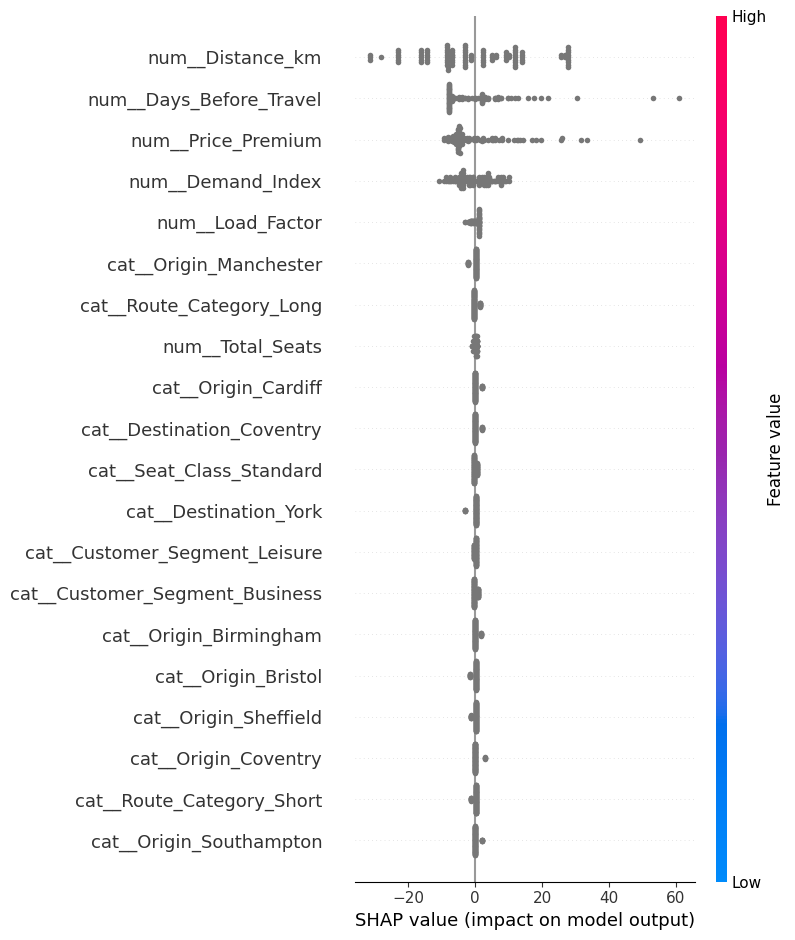

In [ ]:
import shap

with mlflow.start_run(run_name="Linear Regression Model V3 - SHAP Analysis"):
    lr_pipeline.fit(X_train, y_train)
    lr_pred = lr_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, lr_pred)
    mse = mean_squared_error(y_test, lr_pred)
    r2 = r2_score(y_test, lr_pred)
    rmse = np.sqrt(mse)

    mlflow.log_metric("mean_absolute_error", mae)
    mlflow.log_metric("mean_squared_error", mse)
    mlflow.log_metric("r2_score", r2)
    mlflow.log_metric("root_mean_squared_error", rmse)
    
    mlflow.log_param("train_set", X_train.columns)
    mlflow.sklearn.log_model(lr_pipeline, "linear_model")
    
    # SHAP implementation
    xtest_transformed = preprocessor.transform(X_test[:100])  # Transform the first 100 samples for SHAP analysis
    features_names = preprocessor.get_feature_names_out()
    explainer = shap.LinearExplainer(lr_pipeline.named_steps['regressor'], xtest_transformed, feature_names=features_names)
    shap_values = explainer.shap_values(xtest_transformed)
    
    shap.summary_plot(shap_values, xtest_transformed, feature_names=features_names)
    plt.savefig("shap_summary_plot.png")
    mlflow.log_artifact("shap_summary_plot.png")
    plt.close()